In [42]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
# #Importing Model Data
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

# # dx = 250km; Np = 50M;
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
# res='250m'; t_res='1min'; Np_str='50e6'

In [43]:
##############################################
#DATA LOADING

In [44]:
file_path = dir2 + 'Variable_Calculation/OUTPUT/' + f'theta_e_{res}_{t_res}.h5'
th_e_ds1 = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
th_e_ds1 = th_e_ds1.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

In [47]:
def GetData(t):
    w=data1['winterp'].isel(time=t).data
    qc=data1['qc'].isel(time=t).data
    qi=data1['qi'].isel(time=t).data
    RH_v = th_e_ds1['RH_vapor'].isel(time=t).data
    RH_i = th_e_ds1['RH_ice'].isel(time=t).data
    return w,qc,qi,RH_v,RH_i

In [48]:
[w,qc,qi,RH_v,RH_i]=GetData(t=95)

In [49]:
zs,ys,xs=np.round(data1['zh'].data,1),np.round(data1['yh'].data,1),np.round(data1['xh'].data,1)
ys-=ys[0];xs-=xs[0]

In [50]:
##############################################
#PLOTTING FUNCTIONS

In [51]:
def GetSlice(w, qc, qi, RH_v, RH_i, slice_indices=None):
    if slice_indices is None:
        return w.copy(), qc.copy(), qi.copy(), RH_v.copy(), RH_i.copy()

    y1, y2, x1, x2 = slice_indices

    return (
        w[:, y1:y2, x1:x2],
        qc[:, y1:y2, x1:x2],
        qi[:, y1:y2, x1:x2],
        RH_v[:, y1:y2, x1:x2],
        RH_i[:, y1:y2, x1:x2],
    )
def GetMask(w, qc, qi, type1='cloudy', w_thresh=0.5, qcqi_thresh=1e-6):
    cond1 = ((qc) >= qcqi_thresh)
    cond2 = ((qi) >= qcqi_thresh)
    cond3 = ((qc + qi) >= qcqi_thresh)
    cond4 = (w >= w_thresh)

    if type1 == 'cloudy':
        mask = cond1
    elif type1 == 'icy':
        mask = cond2
    elif type1 == 'cloudy&icy':
        mask = cond3
    elif type1 == 'cloudy&ice_updraft':
        mask = cond3 & cond4
    else:
        raise ValueError(f"Unknown type1: {type1}")
    return mask

In [52]:
def plot_qc_slice(axis, qc_slice):

    cf = axis.contourf(qc_slice[z])
    cbar = plt.colorbar(cf, ax=axis, label=r"$q_c\ \mathrm{(g/kg)}$")

    axis.set_title(
        f"z = {zs[z]:.1f} km\n"
        f"y = {ys[y1]:.0f} : {ys[y2]:.0f} km\n"
        f"x = {xs[x1]:.0f} : {xs[x2]:.0f} km"
    )
    return cf, cbar


def PlotProfiles(w_slice, qc_slice, qi_slice, axis, plot_data, type1='cloudy'):
    mask = GetMask(w_slice, qc_slice, qi_slice, type1=type1)

    plot_data_masked = np.full_like(plot_data, np.nan, dtype=float)

    plot_data_masked[mask] = plot_data[mask]

    plot_data_profile = np.nanmean(plot_data_masked, axis=(1, 2))

    axis.plot(plot_data_profile, zs, label=type1)
    axis.set_ylabel('z (km)')
    axis.grid(True)
    axis.set_ylim(bottom=0,top=20)
    axis.legend()


In [53]:
#INDEXING
y1=50;y2=125; x1=150;x2=250;
slice_indices = (y1, y2, x1, x2)
z=15
w_slice, qc_slice, qi_slice, RH_v_slice, RH_i_slice = GetSlice(w, qc, qi, RH_v, RH_i, slice_indices)

/tmp/ipykernel_2077863/3537393927.py:21: RuntimeWarning: Mean of empty slice
  plot_data_profile = np.nanmean(plot_data_masked, axis=(1, 2))


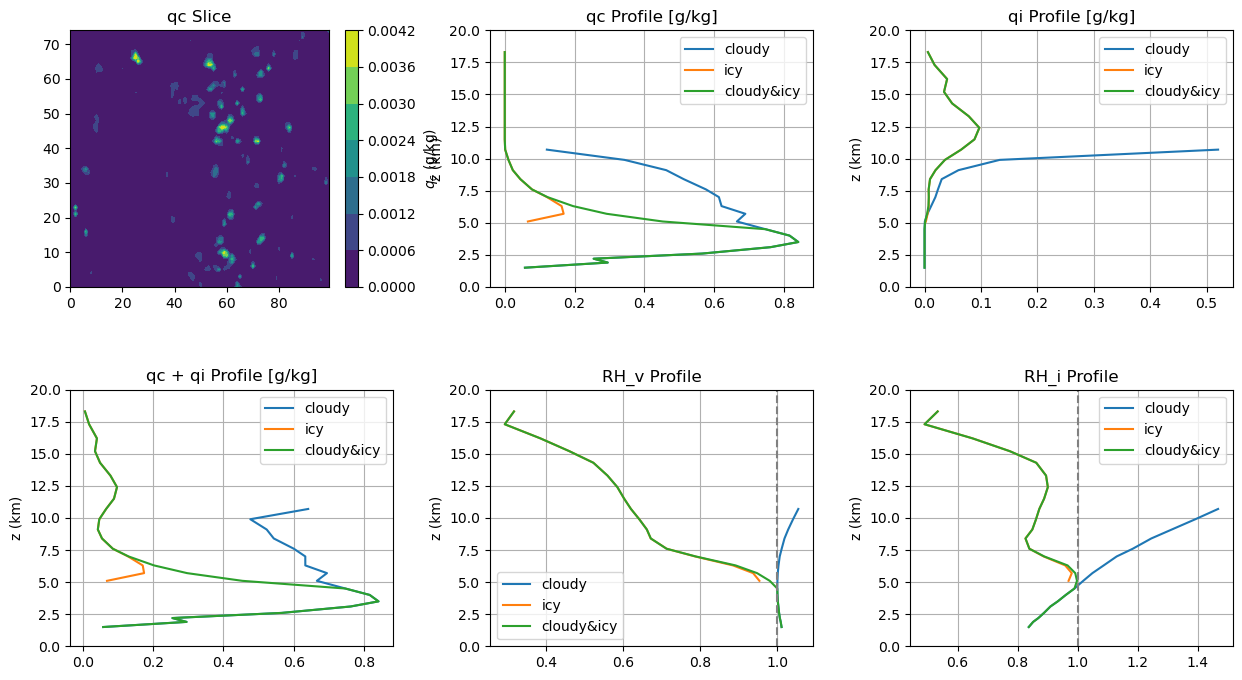

In [54]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

# Panel 1: qc slice (2D field plot)
ax1 = fig.add_subplot(gs[0, 0])
plot_qc_slice(ax1, qc_slice)
ax1.set_title('qc Slice')

# Panel 2: qc profile
ax2 = fig.add_subplot(gs[0, 1])
PlotProfiles(w_slice, qc_slice, qi_slice, ax2, plot_data=qc_slice*1000, type1='cloudy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax2, plot_data=qc_slice*1000, type1='icy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax2, plot_data=qc_slice*1000, type1='cloudy&icy')
ax2.set_title('qc Profile [g/kg]')

# Panel 3: qi profile
ax3 = fig.add_subplot(gs[0, 2])
PlotProfiles(w_slice, qc_slice, qi_slice, ax3, plot_data=qi_slice*1000, type1='cloudy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax3, plot_data=qi_slice*1000, type1='icy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax3, plot_data=qi_slice*1000, type1='cloudy&icy')
ax3.set_title('qi Profile [g/kg]')

# Panel 4: qc+qi profile (moved here after qi)
ax4 = fig.add_subplot(gs[1, 0])
PlotProfiles(w_slice, qc_slice, qi_slice, ax4, plot_data=(qc_slice+qi_slice)*1000, type1='cloudy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax4, plot_data=(qc_slice+qi_slice)*1000, type1='icy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax4, plot_data=(qc_slice+qi_slice)*1000, type1='cloudy&icy')
ax4.set_title('qc + qi Profile [g/kg]')

# Panel 5: RH_v profile
ax5 = fig.add_subplot(gs[1, 1])
PlotProfiles(w_slice, qc_slice, qi_slice, ax5, plot_data=RH_v_slice, type1='cloudy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax5, plot_data=RH_v_slice, type1='icy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax5, plot_data=RH_v_slice, type1='cloudy&icy')
ax5.set_title('RH_v Profile')
ax5.axvline(1, color='grey', linestyle='--')

# Panel 6: RH_i profile
ax6 = fig.add_subplot(gs[1, 2])
PlotProfiles(w_slice, qc_slice, qi_slice, ax6, plot_data=RH_i_slice, type1='cloudy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax6, plot_data=RH_i_slice, type1='icy')
PlotProfiles(w_slice, qc_slice, qi_slice, ax6, plot_data=RH_i_slice, type1='cloudy&icy')
ax6.set_title('RH_i Profile')
ax6.axvline(1, color='grey', linestyle='--')